# MATH 373: Introduction to Statistical Learning — Final Project
**Professor:** James D. Wilson  
**Authors:** Disha Khati, Kailash Turimella, Tyler Soong

## 1. Imports and setup
All required libraries are loaded here. We set `random_state` and `np.random.seed` globally for full reproducibility across the notebook.

In [1]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB, GaussianNB
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
import re
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
np.random.seed(42)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

## 2. Loading data
Loading the IMDB dataset (50,000 movie reviews, balanced between positive and negative sentiment). We inspect the shape, class distribution, and a sample of raw reviews before any processing. This is done to get the lay of the land.

In [2]:
df = pd.read_csv("IMDBDataset.csv")
print("Shape of the dataset: " + str(df.shape))
print("Class Distribution:")
print(df['sentiment'].value_counts())
display(df.head(10))

Shape of the dataset: (50000, 2)
Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


## 3. Text Baptism
Raw reviews contain HTML artifacts (e.g. `<br />`), punctuation, and stopwords that add noise without predictive signal. We strip these out, lowercase everything, and lemmatize each token to reduce words to their base form (e.g. "running" → "run"). We are also encoding labels here: `negative=0`, `positive=1`.

In [18]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)          # removing HTML tags like <br />
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # removing punctuation/numbers
    text = text.lower()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
print("Cleaning done.") #Sanity check
df[['review', 'clean_review']].head(2)

#Encoding labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])  # negative=0, positive=1
print(le.classes_)  # verify ordering

Cleaning done.
['negative' 'positive']


### Visualizing the baptism for the people to see...

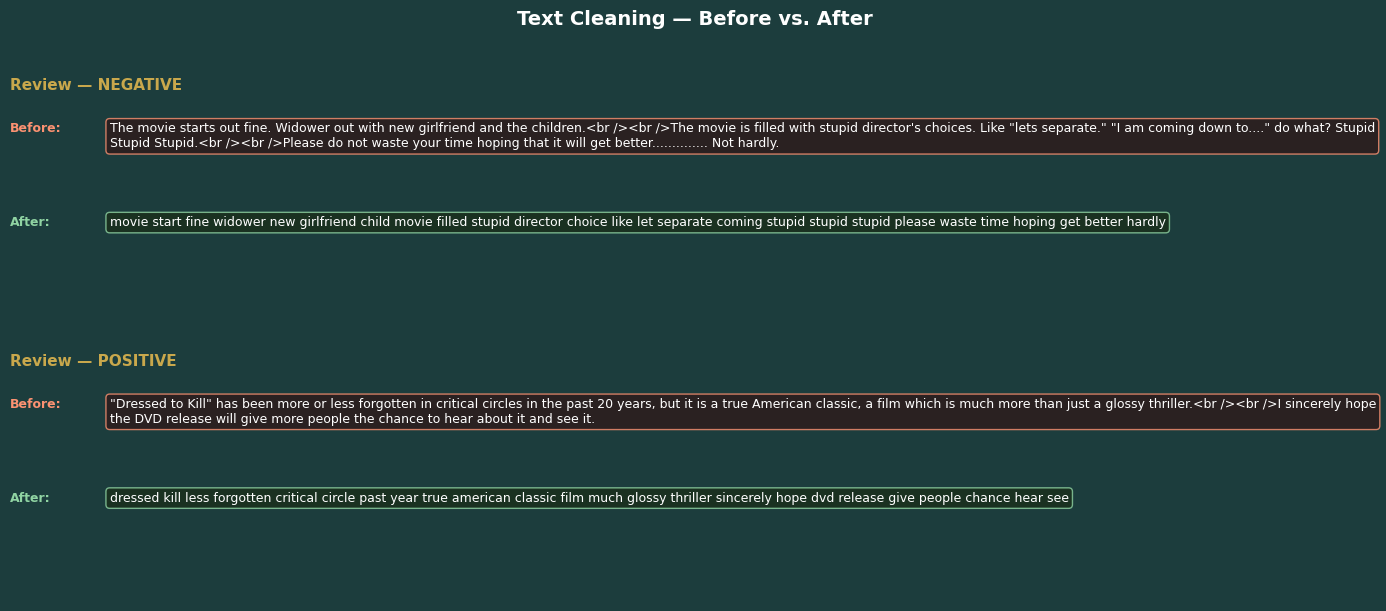

In [ ]:
# Filtering for short reviews with HTML tags for a clear before/after
df['review_length'] = df['review'].str.split().str.len()
df['clean_length'] = df['clean_review'].str.split().str.len()

# Picking one positive and one negative short review that has HTML tags
short_reviews = df[
    (df['review_length'] < 80) &
    (df['review_length'] > 30) &
    (df['review'].str.contains('<br'))
].groupby('sentiment')[['review', 'clean_review', 'sentiment', 'review_length', 'clean_length']]\
 .apply(lambda x: x.sample(1, random_state=42), include_groups=False)\
.reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.patch.set_facecolor('#1c3d3d')

for i, (_, row) in enumerate(short_reviews.iterrows()):
    raw = row['review']
    cleaned = row['clean_review']

    axes[i].axis('off')
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_facecolor('#1c3d3d')

    axes[i].text(0, 0.95, f"Review — {row['sentiment'].upper()}",
                 fontsize=11, fontweight='bold', color='#c9a84c',
                 transform=axes[i].transAxes, va='top')

    axes[i].text(0, 0.78, 'Before:',
                 fontsize=9, fontweight='bold', color='#fc9272',
                 transform=axes[i].transAxes, va='top')

    axes[i].text(0.08, 0.78, raw,
                 fontsize=9, color='white',
                 transform=axes[i].transAxes, va='top',
                 wrap=True,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#2e1a1a', edgecolor='#fc9272', alpha=0.8))

    axes[i].text(0, 0.42, 'After:',
                 fontsize=9, fontweight='bold', color='#90d4a3',
                 transform=axes[i].transAxes, va='top')

    axes[i].text(0.08, 0.42, cleaned,
                 fontsize=9, color='white',
                 transform=axes[i].transAxes, va='top',
                 wrap=True,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a2e1a', edgecolor='#90d4a3', alpha=0.8))

plt.suptitle('Text Cleaning — Before vs. After', fontsize=14,
             fontweight='bold', color='white', y=1.01)
plt.subplots_adjust(hspace=0.15)
plt.tight_layout()
plt.show()

## 4. Train / test split
We use an 80/20 stratified split to ensure class balance is preserved in both sets. The vectorizers are fit **only on the training set** to prevent data leakage.

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Train: 40000 | Test: 10000


## 5. TF-IDF feature extraction
TF-IDF (Term Frequency-Inverse Document Frequency) weights each word by how often it appears in a review relative to how common it is across all reviews. We use unigrams and bigrams with a vocabulary cap of 10,000 features, producing a sparse float matrix.

In [5]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))  # unigrams + bigrams
X_train_tfidf = tfidf.fit_transform(train_df['clean_review'])    # fitting ONLY on train
X_test_tfidf  = tfidf.transform(test_df['clean_review'])         # transforming test

y_train = train_df['label']
y_test  = test_df['label']

In [36]:
review_idx = 0
review_text = test_df['clean_review'].iloc[review_idx]
print("Clean review:", review_text[:200])
print("Actual label:", le.classes_[y_test.iloc[review_idx]])

# Getting feature names and the row
feature_names = tfidf.get_feature_names_out()
row = X_test_tfidf[review_idx]
nonzero_idx = row.nonzero()[1]

# Getting raw counts for TF from the count vectorizer
row_counts = X_test_counts_mnb[review_idx]

# Computing IDF directly from the fitted tfidf vectorizer
idf_values = tfidf.idf_

# Building the table
table_data = []
for i in nonzero_idx:
    word = feature_names[i]
    # finding index in count vectorizer vocabulary
    if word in count_vec_mnb.vocabulary_:
        count_idx = count_vec_mnb.vocabulary_[word]
        tf = row_counts[0, count_idx]
    else:
        tf = 0
    idf = idf_values[i]
    tfidf_score = row[0, i]
    table_data.append((word, int(tf), round(idf, 4), round(tfidf_score, 4)))

# Sorting by TF-IDF score descending
table_data = sorted(table_data, key=lambda x: x[3], reverse=True)

# Top 10 highest TF-IDF scores
top = sorted(table_data, key=lambda x: x[3], reverse=True)[:10]

# Top 10 lowest TF-IDF scores (non-zero)
bottom = sorted(table_data, key=lambda x: x[3])[:10]

# Combine with a separator
separator = [('...', '', '', '')]
combined = top + separator + bottom

df_contrast = pd.DataFrame(combined, columns=['Word', 'TF (raw count)', 'IDF', 'TF-IDF Score'])
print(df_contrast.to_string(index=False, col_space=20))

Clean review: yes mtv really way market daria started clever teenage angstcomment everything suck make viewer feel better sucky teenage life sitcom mutated deal problemscharade used watch daria time loved sitting w
Actual label: negative
Word                 TF (raw count)       IDF                  TF-IDF Score        
      teenage        2                     5.5031               0.3228             
           ok        2                     4.3354               0.2543             
  make viewer        1                     7.3482               0.2155             
          mtv        1                     6.7683               0.1985             
every episode        1                     6.7446               0.1978             
         bite        1                     6.3817               0.1872             
        point        2                     3.1108               0.1825             
       sitcom        1                     5.9799               0.1754             
      

In [ ]:
from sklearn.feature_selection import chi2

# Run chi2 on TF-IDF features against sentiment labels
chi2_scores, p_values = chi2(X_train_tfidf, y_train)

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Top 20 most correlated words overall
top_idx = np.argsort(chi2_scores)[-20:][::-1]
for i in top_idx:
    print(f"{feature_names[i]:20s} chi2={chi2_scores[i]:.2f}  p={p_values[i]:.4f}")

bad                  chi2=251.65  p=0.0000
worst                chi2=204.23  p=0.0000
waste                chi2=149.14  p=0.0000
awful                chi2=138.63  p=0.0000
great                chi2=126.59  p=0.0000
terrible             chi2=116.05  p=0.0000
excellent            chi2=97.52  p=0.0000
waste time           chi2=96.12  p=0.0000
stupid               chi2=94.72  p=0.0000
worst movie          chi2=90.38  p=0.0000
horrible             chi2=89.34  p=0.0000
boring               chi2=88.26  p=0.0000
worse                chi2=84.20  p=0.0000
wonderful            chi2=80.15  p=0.0000
one best             chi2=72.65  p=0.0000
poor                 chi2=71.75  p=0.0000
one worst            chi2=67.86  p=0.0000
crap                 chi2=64.29  p=0.0000
nothing              chi2=63.93  p=0.0000
love                 chi2=62.14  p=0.0000


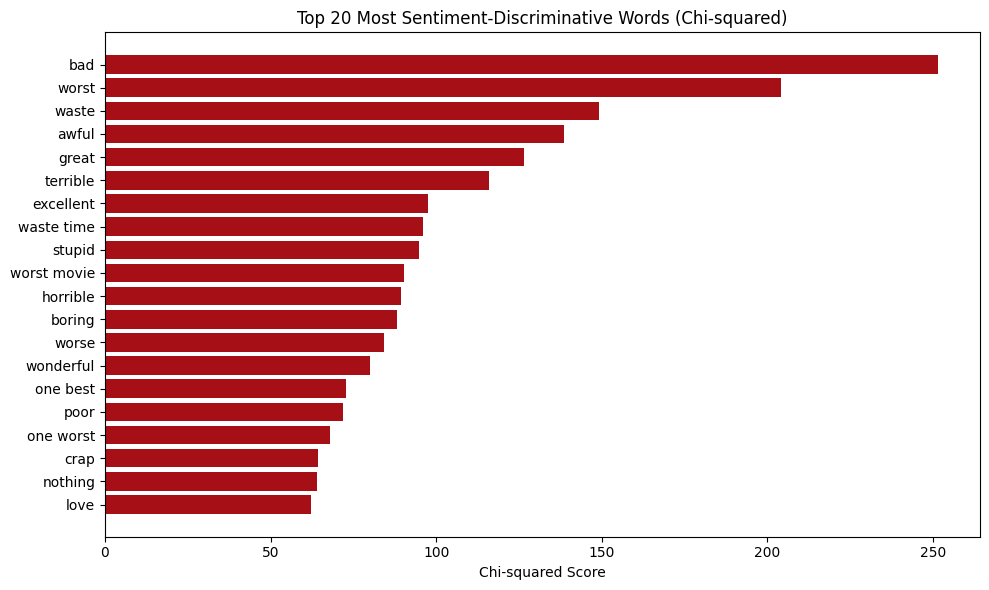

In [9]:
# Bar chart of top 20 most discriminative words
top_n = 20
top_idx = np.argsort(chi2_scores)[-top_n:][::-1]
top_words = [feature_names[i] for i in top_idx]
top_scores = [chi2_scores[i] for i in top_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], top_scores[::-1], color='#a50f15')
plt.xlabel('Chi-squared Score')
plt.title('Top 20 Most Sentiment-Discriminative Words (Chi-squared)')
plt.tight_layout()
plt.show()

## 6. Naive Bayes classifiers

### 6a. ComplementNB on TF-IDF
Since TF-IDF produces float values rather than integer counts, we use `ComplementNB` which handles continuous non-negative features better than standard `MultinomialNB` and estimates class probabilities using the complement of each class rather than the class itself.

In [11]:
nb_tfidf = ComplementNB()
nb_tfidf.fit(X_train_tfidf, y_train)
preds_tfidf = nb_tfidf.predict(X_test_tfidf)
print("=== TF-IDF + ComplementNB ===")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf):.4f}")
print(classification_report(y_test, preds_tfidf, target_names=le.classes_))

=== TF-IDF + ComplementNB ===
Accuracy: 0.8651
              precision    recall  f1-score   support

    negative       0.88      0.85      0.86      5000
    positive       0.85      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### 6b. MultinomialNB on raw counts
`MultinomialNB` requires non-negative integer counts, so we fit a separate `CountVectorizer` for this model. This lets us compare the effect of feature representation (TF-IDF floats vs. raw counts) on the same algorithm family.

In [12]:
count_vec_mnb = CountVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_counts_mnb = count_vec_mnb.fit_transform(train_df['clean_review'])
X_test_counts_mnb  = count_vec_mnb.transform(test_df['clean_review'])

nb_multi = MultinomialNB(alpha=1.0)
nb_multi.fit(X_train_counts_mnb, y_train)
preds_multi = nb_multi.predict(X_test_counts_mnb)

print("=== CountVectorizer + MultinomialNB ===")
print(f"Accuracy: {accuracy_score(y_test, preds_multi):.4f}")
print(classification_report(y_test, preds_multi, target_names=le.classes_))

=== CountVectorizer + MultinomialNB ===
Accuracy: 0.8578
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      5000
    positive       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



## 7. LDA topic modeling
LDA (Latent Dirichlet Allocation) is an unsupervised algorithm that models each document as a mixture of latent topics, where each topic is a distribution over words. We fit 10 topics on a bag-of-words matrix (LDA requires raw counts, not TF-IDF). Each review is then represented as a 10-dimensional vector of topic proportions. The bar charts below show the top 10 words per topic — these can be interpreted and named manually.

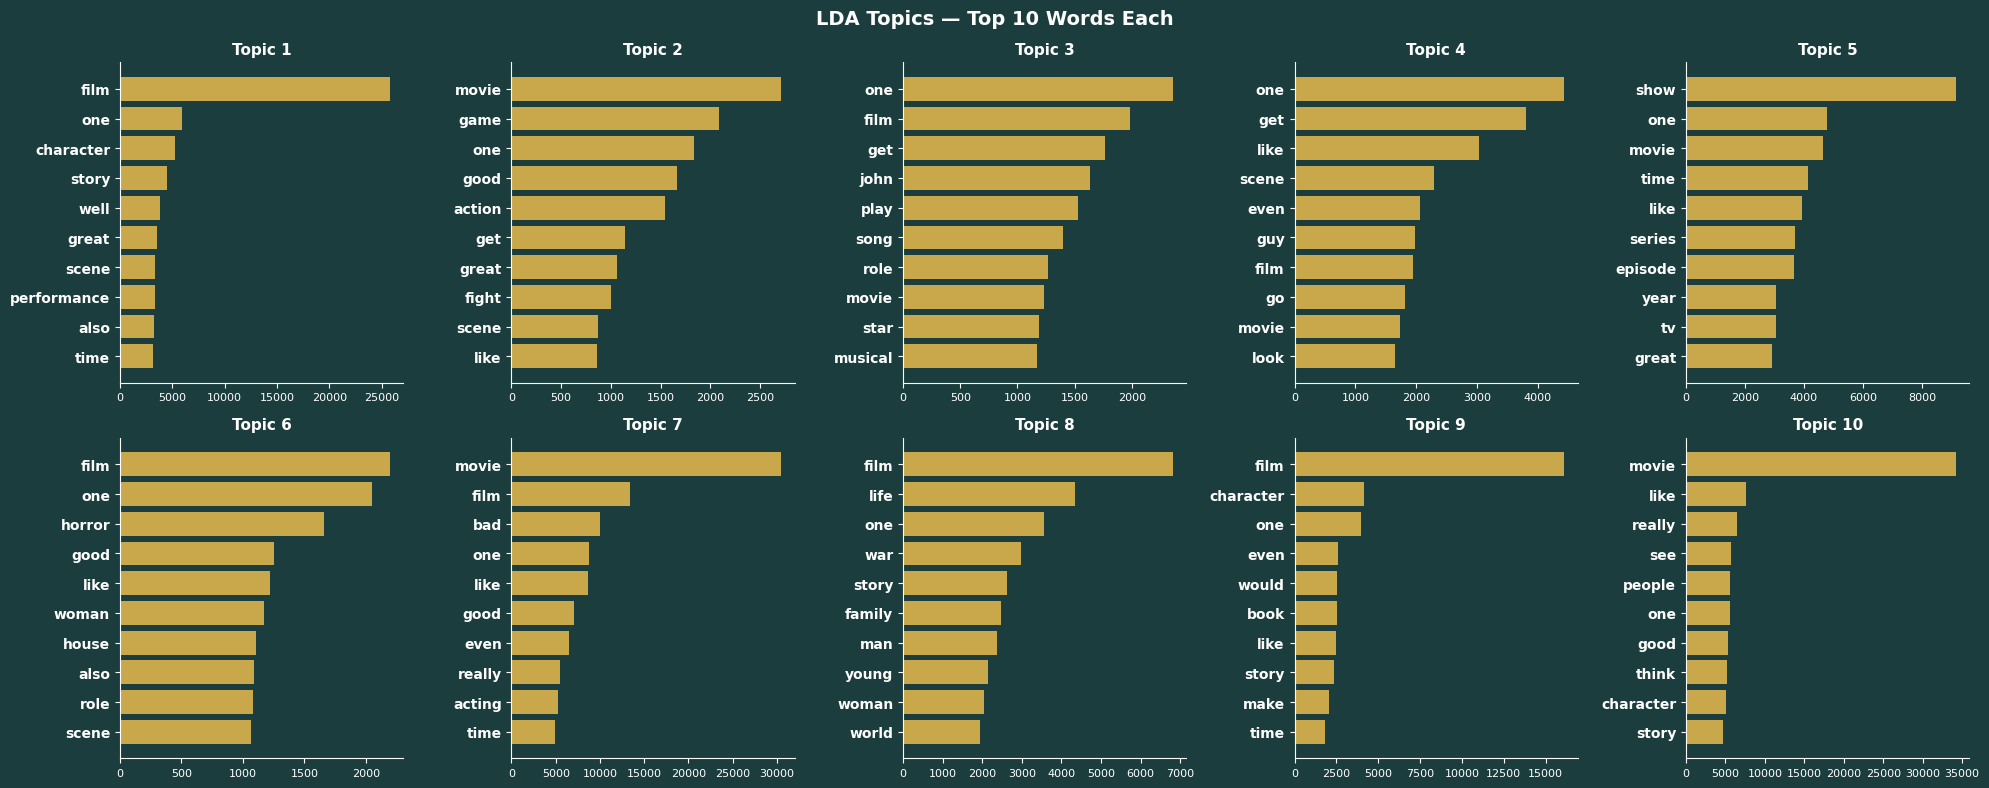

In [34]:
# LDA needs raw counts, not TF-IDF — using a separate CountVectorizer
count_vec_lda = CountVectorizer(max_features=10000)
X_train_counts_lda = count_vec_lda.fit_transform(train_df['clean_review'])
X_test_counts_lda  = count_vec_lda.transform(test_df['clean_review'])

N_TOPICS = 10
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, n_jobs=1)
X_train_lda = lda.fit_transform(X_train_counts_lda)   # shape: (n_train, 10)
X_test_lda  = lda.transform(X_test_counts_lda)

vocab = count_vec_lda.get_feature_names_out()
n_top_words = 10

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor('#1c3d3d')

for i, (ax, topic) in enumerate(zip(axes.flatten(), lda.components_)):
    top_idx = topic.argsort()[-n_top_words:][::-1]
    top_words = [vocab[j] for j in top_idx]
    top_weights = topic[top_idx]
    ax.barh(top_words[::-1], top_weights[::-1], color='#c9a84c')
    ax.set_facecolor('#1c3d3d')
    ax.set_title(f"Topic {i+1}", fontsize=11, color='white', fontweight='bold')
    ax.tick_params(axis='y', labelsize=10, colors='white')
    ax.tick_params(axis='x', colors='white', labelsize=8)
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Make y-axis word labels bold
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.suptitle("LDA Topics — Top 10 Words Each", fontsize=14, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

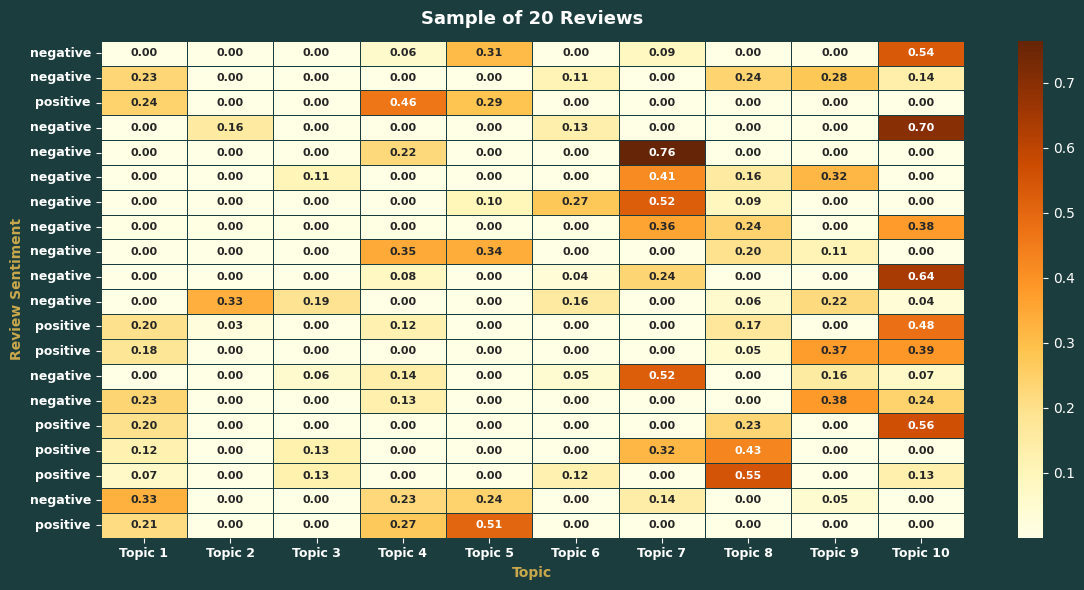

In [39]:
# Visualizing review-topic distributions for a few test reviews
sample_idx = range(20)
sample_lda = X_test_lda[sample_idx]
sample_labels = [le.classes_[y_test.iloc[i]] for i in sample_idx]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1c3d3d')
ax.set_facecolor('#1c3d3d')

sns.heatmap(sample_lda,
            xticklabels=[f"Topic {i+1}" for i in range(N_TOPICS)],
            yticklabels=sample_labels,
            cmap='YlOrBr',
            annot=True, fmt='.2f',
            linewidths=0.5,
            linecolor='#1c3d3d',
            annot_kws={'size': 8, 'weight': 'bold'},
            ax=ax)

ax.set_title('Sample of 20 Reviews',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Topic', fontsize=10, fontweight='bold', color='#c9a84c')
ax.set_ylabel('Review Sentiment', fontsize=10, fontweight='bold', color='#c9a84c')
ax.tick_params(axis='x', colors='white', labelsize=9)
ax.tick_params(axis='y', colors='white', labelsize=9)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

# Color the colorbar to match
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='white')
cbar.ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.show()

### 7a. GaussianNB on LDA features
LDA outputs topic proportion vectors (floats that sum to 1), so we use `GaussianNB` which assumes continuous, normally distributed features.

In [42]:
nb_lda = GaussianNB()
nb_lda.fit(X_train_lda, y_train)
preds_lda = nb_lda.predict(X_test_lda)

print("=== LDA + GaussianNB ===")
print(f"Accuracy: {accuracy_score(y_test, preds_lda):.4f}")
print(classification_report(y_test, preds_lda, target_names=le.classes_))

=== LDA + GaussianNB ===
Accuracy: 0.7951
              precision    recall  f1-score   support

    negative       0.80      0.78      0.79      5000
    positive       0.79      0.81      0.80      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



## 8. Combined features: TF-IDF + LDA
We horizontally stack the TF-IDF sparse matrix and the LDA topic matrix to test whether semantic topic features add predictive signal on top of lexical TF-IDF features.

In [43]:
X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_lda)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_test_lda)])

nb_combined = ComplementNB()
nb_combined.fit(X_train_combined, y_train)
preds_combined = nb_combined.predict(X_test_combined)

print("=== TF-IDF + LDA Combined + ComplementNB ===")
print(f"Accuracy: {accuracy_score(y_test, preds_combined):.4f}")
print(classification_report(y_test, preds_combined, target_names=le.classes_))

=== TF-IDF + LDA Combined + ComplementNB ===
Accuracy: 0.8607
              precision    recall  f1-score   support

    negative       0.88      0.83      0.86      5000
    positive       0.84      0.89      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



## 9. Random Forest classifiers
Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. Unlike Naive Bayes, it makes no assumptions about the distribution of input features, making it compatible with all three feature sets (TF-IDF, LDA, and combined) using the same classifier. This allows us to isolate the effect of feature representation independently of the model choice.


In [44]:
# TF-IDF + Random Forest
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tfidf.fit(X_train_tfidf, y_train)
preds_rf_tfidf = rf_tfidf.predict(X_test_tfidf)

print("=== TF-IDF + Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, preds_rf_tfidf):.4f}")
print(classification_report(y_test, preds_rf_tfidf, target_names=le.classes_))

# LDA + Random Forest
rf_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_lda.fit(X_train_lda, y_train)
preds_rf_lda = rf_lda.predict(X_test_lda)

print("=== LDA + Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, preds_rf_lda):.4f}")
print(classification_report(y_test, preds_rf_lda, target_names=le.classes_))

# Combined + Random Forest
rf_combined = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_combined.fit(X_train_combined, y_train)
preds_rf_combined = rf_combined.predict(X_test_combined)

print("=== TF-IDF + LDA Combined + Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, preds_rf_combined):.4f}")
print(classification_report(y_test, preds_rf_combined, target_names=le.classes_))

=== TF-IDF + Random Forest ===
Accuracy: 0.8561
              precision    recall  f1-score   support

    negative       0.85      0.86      0.86      5000
    positive       0.86      0.85      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

=== LDA + Random Forest ===
Accuracy: 0.8182
              precision    recall  f1-score   support

    negative       0.82      0.82      0.82      5000
    positive       0.82      0.81      0.82      5000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000

=== TF-IDF + LDA Combined + Random Forest ===
Accuracy: 0.8644
              precision    recall  f1-score   support

    negative       0.86      0.87      0.86      5000
    positive       0.87      0.86      0.86      5000

    accuracy              

## 10. Model comparison
Side-by-side accuracy comparison across all seven models — four Naive Bayes variants and three Random Forest models. The comparison illustrates how both feature representation and classifier choice impact sentiment prediction performance.

  Model                      Accuracy
0     TF-IDF + ComplementNB  0.8651  
1    Counts + MultinomialNB  0.8578  
2          LDA + GaussianNB  0.7951  
3     TF-IDF + LDA Combined  0.8607  
4    TF-IDF + Random Forest  0.8561  
5       LDA + Random Forest  0.8182  
6  Combined + Random Forest  0.8644  


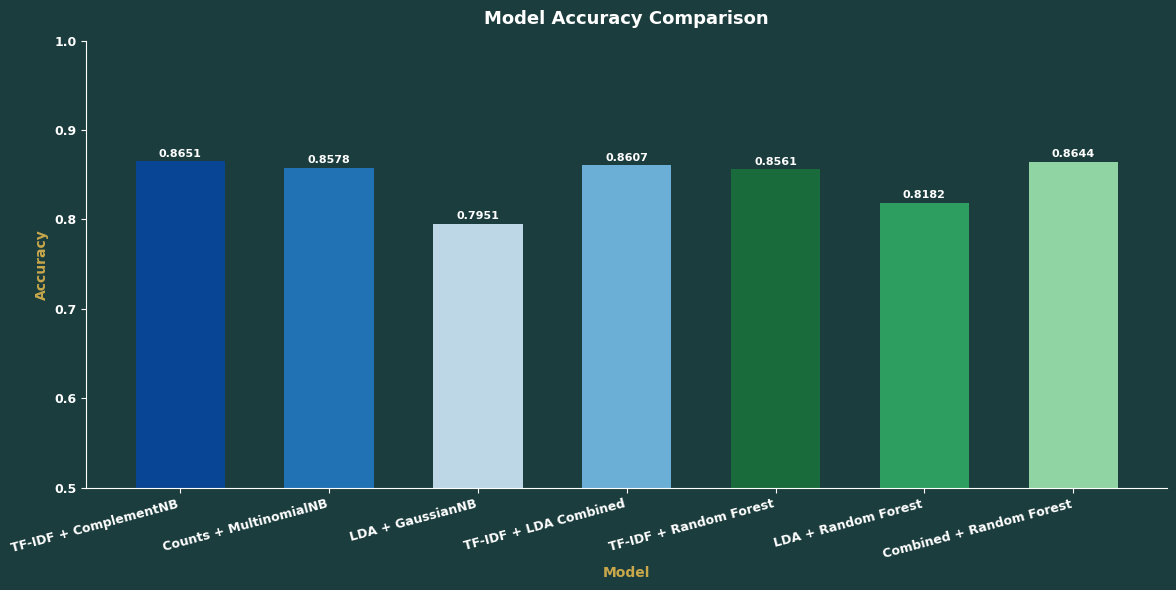

In [45]:
results = pd.DataFrame({
    'Model': [
        'TF-IDF + ComplementNB',
        'Counts + MultinomialNB',
        'LDA + GaussianNB',
        'TF-IDF + LDA Combined',
        'TF-IDF + Random Forest',
        'LDA + Random Forest',
        'Combined + Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, preds_tfidf),
        accuracy_score(y_test, preds_multi),
        accuracy_score(y_test, preds_lda),
        accuracy_score(y_test, preds_combined),
        accuracy_score(y_test, preds_rf_tfidf),
        accuracy_score(y_test, preds_rf_lda),
        accuracy_score(y_test, preds_rf_combined)
    ]
})
print(results)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1c3d3d')
ax.set_facecolor('#1c3d3d')

bars = ax.bar(results['Model'], results['Accuracy'], width=0.6,
              color=['#084594', '#2171b5', '#bdd7e7', '#6baed6', '#1a6b3c', '#2d9e5f', '#90d4a3'])

ax.set_ylim(0.5, 1.0)
ax.set_title('Model Accuracy Comparison',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_ylabel('Accuracy', fontsize=10, fontweight='bold', color='#c9a84c')
ax.set_xlabel('Model', fontsize=10, fontweight='bold', color='#c9a84c')
ax.tick_params(axis='x', colors='white', labelsize=9)
ax.tick_params(axis='y', colors='white', labelsize=9)
plt.xticks(rotation=15, ha='right')

for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# Value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.003,
            f'{height:.4f}', ha='center', va='bottom',
            color='white', fontsize=8, fontweight='bold')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 11. Confusion Matrices
### 11a. Confusion Matrices — Naive Bayes
Confusion matrices for all four Naive Bayes models. Each model uses a different NB variant suited to its input feature type: ComplementNB for TF-IDF floats, MultinomialNB for raw integer counts, GaussianNB for LDA topic proportions, and ComplementNB again for the combined matrix which is dominated by TF-IDF features.

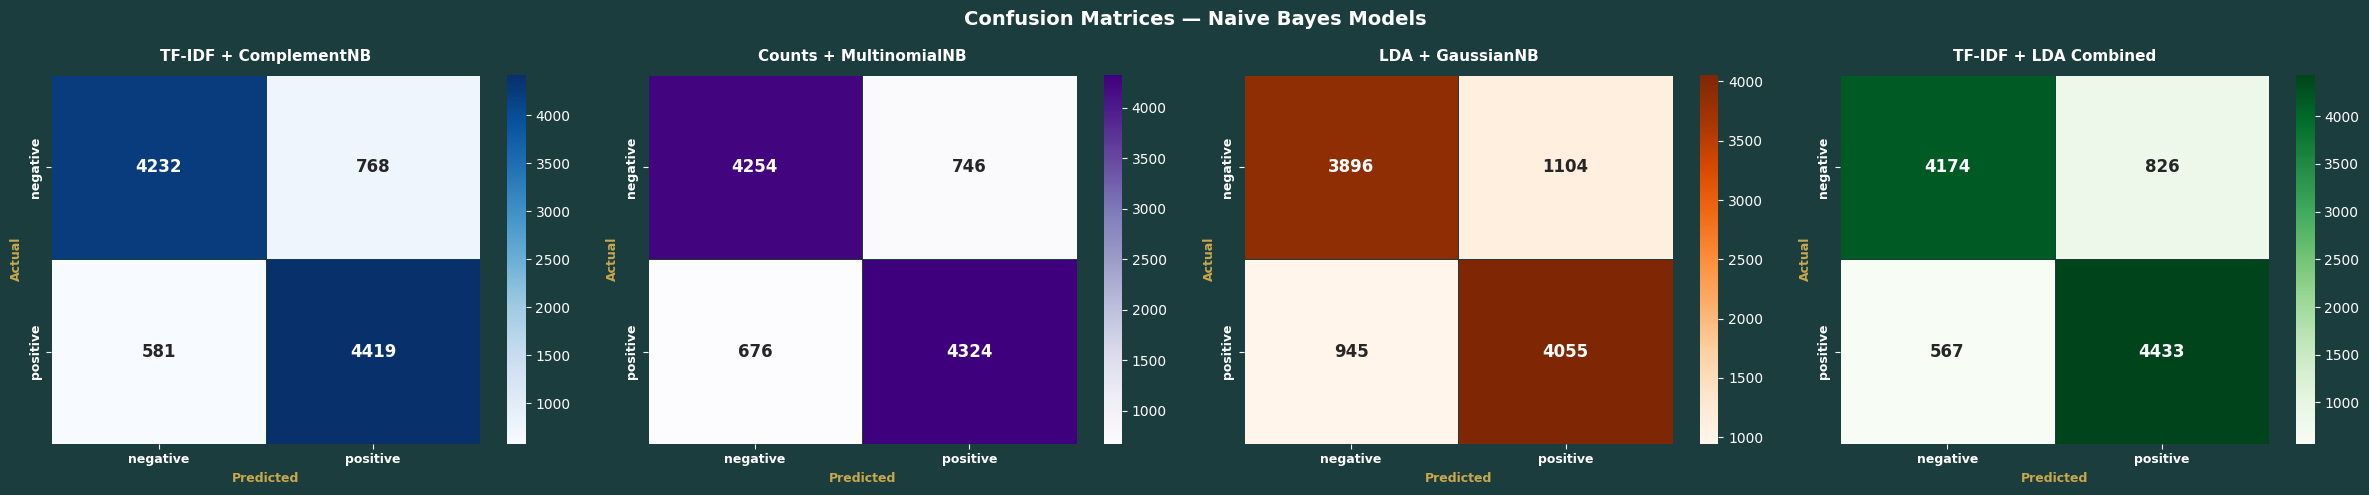

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.patch.set_facecolor('#1c3d3d')

cms = [
    (confusion_matrix(y_test, preds_tfidf),    'TF-IDF + ComplementNB',  'Blues'),
    (confusion_matrix(y_test, preds_multi),    'Counts + MultinomialNB', 'Purples'),
    (confusion_matrix(y_test, preds_lda),      'LDA + GaussianNB',       'Oranges'),
    (confusion_matrix(y_test, preds_combined), 'TF-IDF + LDA Combined',  'Greens'),
]

for ax, (cm, title, cmap) in zip(axes, cms):
    ax.set_facecolor('#1c3d3d')
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap=cmap, ax=ax,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5, linecolor='#1c3d3d')
    ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=10)
    ax.set_ylabel('Actual', fontsize=9, fontweight='bold', color='#c9a84c')
    ax.set_xlabel('Predicted', fontsize=9, fontweight='bold', color='#c9a84c')
    ax.tick_params(axis='x', colors='white', labelsize=9)
    ax.tick_params(axis='y', colors='white', labelsize=9)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors='white')

plt.suptitle('Confusion Matrices — Naive Bayes Models',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

### 11b. Confusion Matrices — Random Forest
Confusion matrices for all three Random Forest models. Comparing these side by side with the Naive Bayes confusion matrices above shows how the two classifier families differ in their error patterns across feature representations.

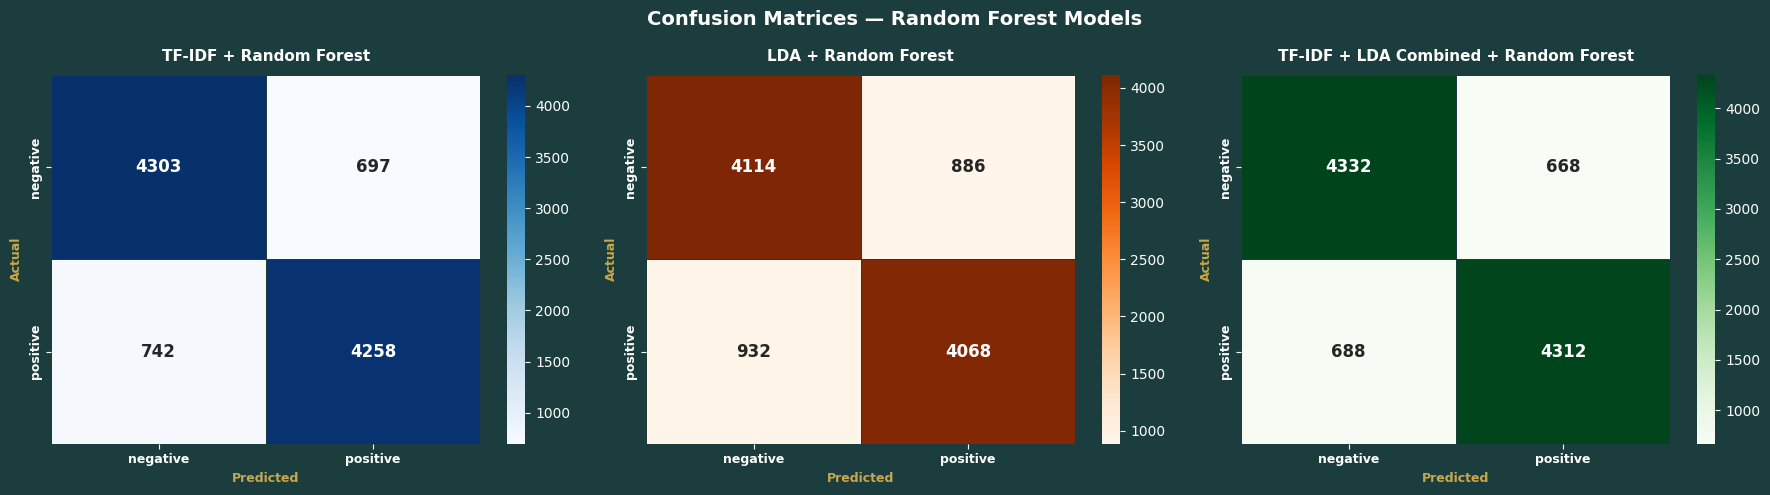

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1c3d3d')

cms = [
    (confusion_matrix(y_test, preds_rf_tfidf),    'TF-IDF + Random Forest',          'Blues'),
    (confusion_matrix(y_test, preds_rf_lda),       'LDA + Random Forest',             'Oranges'),
    (confusion_matrix(y_test, preds_rf_combined),  'TF-IDF + LDA Combined + Random Forest', 'Greens'),
]

for ax, (cm, title, cmap) in zip(axes, cms):
    ax.set_facecolor('#1c3d3d')
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap=cmap, ax=ax,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5, linecolor='#1c3d3d')
    ax.set_title(title, fontsize=11, fontweight='bold', color='white', pad=10)
    ax.set_ylabel('Actual', fontsize=9, fontweight='bold', color='#c9a84c')
    ax.set_xlabel('Predicted', fontsize=9, fontweight='bold', color='#c9a84c')
    ax.tick_params(axis='x', colors='white', labelsize=9)
    ax.tick_params(axis='y', colors='white', labelsize=9)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors='white')

plt.suptitle('Confusion Matrices — Random Forest Models',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

## 12. Vectorizer comparison
We compare `CountVectorizer` (raw word counts) and `TfidfVectorizer` (weighted term frequencies) using the same classifier — `ComplementNB` — to isolate the effect of vectorization strategy independent of model choice. CountVectorizer treats all words equally by frequency, while TF-IDF downweights words that appear across many documents and therefore carry less discriminative signal.

=== CountVectorizer + ComplementNB ===
Accuracy: 0.8578
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      5000
    positive       0.85      0.86      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

=== TfidfVectorizer + ComplementNB ===
Accuracy: 0.8651
              precision    recall  f1-score   support

    negative       0.88      0.85      0.86      5000
    positive       0.85      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



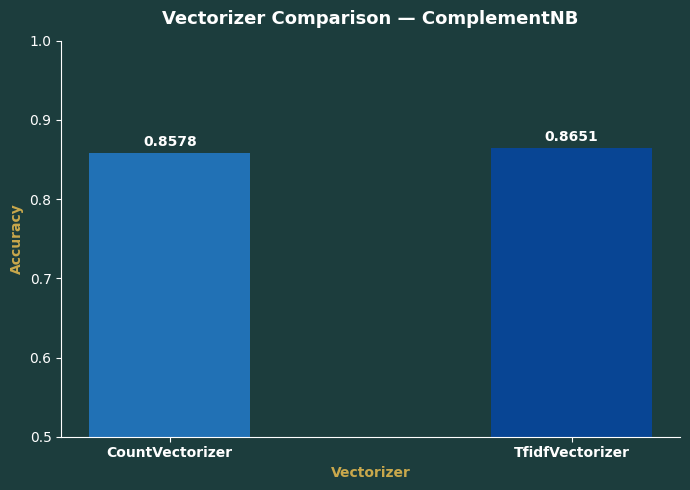

In [40]:
# ComplementNB on both for a fair comparison (same model, different vectorizer)
nb_count = ComplementNB()
nb_count.fit(X_train_counts_mnb, y_train)
preds_count = nb_count.predict(X_test_counts_mnb)

nb_tfidf_cmp = ComplementNB()
nb_tfidf_cmp.fit(X_train_tfidf, y_train)
preds_tfidf_cmp = nb_tfidf_cmp.predict(X_test_tfidf)

print("=== CountVectorizer + ComplementNB ===")
print(f"Accuracy: {accuracy_score(y_test, preds_count):.4f}")
print(classification_report(y_test, preds_count, target_names=le.classes_))

print("=== TfidfVectorizer + ComplementNB ===")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf_cmp):.4f}")
print(classification_report(y_test, preds_tfidf_cmp, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#1c3d3d')
ax.set_facecolor('#1c3d3d')

vec_results = pd.DataFrame({
    'Vectorizer': ['CountVectorizer', 'TfidfVectorizer'],
    'Accuracy': [
        accuracy_score(y_test, preds_count),
        accuracy_score(y_test, preds_tfidf_cmp)
    ]
})

bars = ax.bar(vec_results['Vectorizer'], vec_results['Accuracy'],
              color=['#2171b5', '#084594'], width=0.4)

ax.set_ylim(0.5, 1.0)
ax.set_title('Vectorizer Comparison — ComplementNB',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_ylabel('Accuracy', fontsize=10, fontweight='bold', color='#c9a84c')
ax.set_xlabel('Vectorizer', fontsize=10, fontweight='bold', color='#c9a84c')
ax.tick_params(axis='x', colors='white', labelsize=10)
ax.tick_params(axis='y', colors='white', labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
            f'{height:.4f}', ha='center', va='bottom',
            color='white', fontsize=10, fontweight='bold')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()